# Notebook 01 — Data Inspection

Goal: Load labels.json, match labels with available images, display 5 images with metadata.

**This is practice data only. Not Gigaphoton BI Tool data.**

In [1]:
# STEP 1: Imports
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

print('Libraries loaded OK')

Libraries loaded OK


In [ ]:
# STEP 2: Set paths — update DATASET_PATH to where you extracted the ZIP
DATASET_PATH = Path('../data/laser_dataset')
IMAGES_PATH  = DATASET_PATH / 'images'
LABELS_PATH  = DATASET_PATH / 'labels.json'

assert DATASET_PATH.exists(), f'Dataset not found at {DATASET_PATH}'
print(f'Dataset found: {DATASET_PATH}')

Dataset found: ../data/laser_dataset


In [6]:
# STEP 3: Load labels.json
with open(LABELS_PATH) as f:
    all_labels = json.load(f)

print(f'Total label records in labels.json : {len(all_labels)}')
print(f'Fields in each record              : {list(all_labels[0].keys())}')

Total label records in labels.json : 3984
Fields in each record              : ['Date', 'Timestamp', 'Experiment Number', 'X Axis Gaussian Equation', 'Y Axis Gaussian Equation', 'Gaussian Fit % along X', 'Gaussian Fit % along Y', 'X Axis Centroid', 'Y Axis Centroid', 'Major Axis Beam Width', 'Minor Axis Beam Width', 'Effective Diameter', 'Ellipticity', 'Iris Position', 'Z Position', 'Pitch Position', 'Yaw Position', 'Power Measurement', 'Exposure Time', 'filename']


In [7]:
# STEP 4: Find which images are actually in the images/ folder
available_images = set(
    os.path.splitext(f)[0]          # strip .png extension
    for f in os.listdir(IMAGES_PATH)
    if f.endswith('.png')
)

print(f'Images in folder: {len(available_images)}')

Images in folder: 500


In [8]:
# STEP 5: Filter labels — keep only records that have a matching image
# WARNING: labels.json has 3984 records but only 500 images are included.
# Always filter before using. Never assume all labels have images.
matched_labels = [
    record for record in all_labels
    if record.get('filename') in available_images
]

print(f'Total label records  : {len(all_labels)}')
print(f'Labels with images   : {len(matched_labels)}')
print(f'Labels without images: {len(all_labels) - len(matched_labels)}')
print()
print('WARNING: Only use matched_labels for training. Never use unmatched records.')

Total label records  : 3984
Labels with images   : 500
Labels without images: 3484



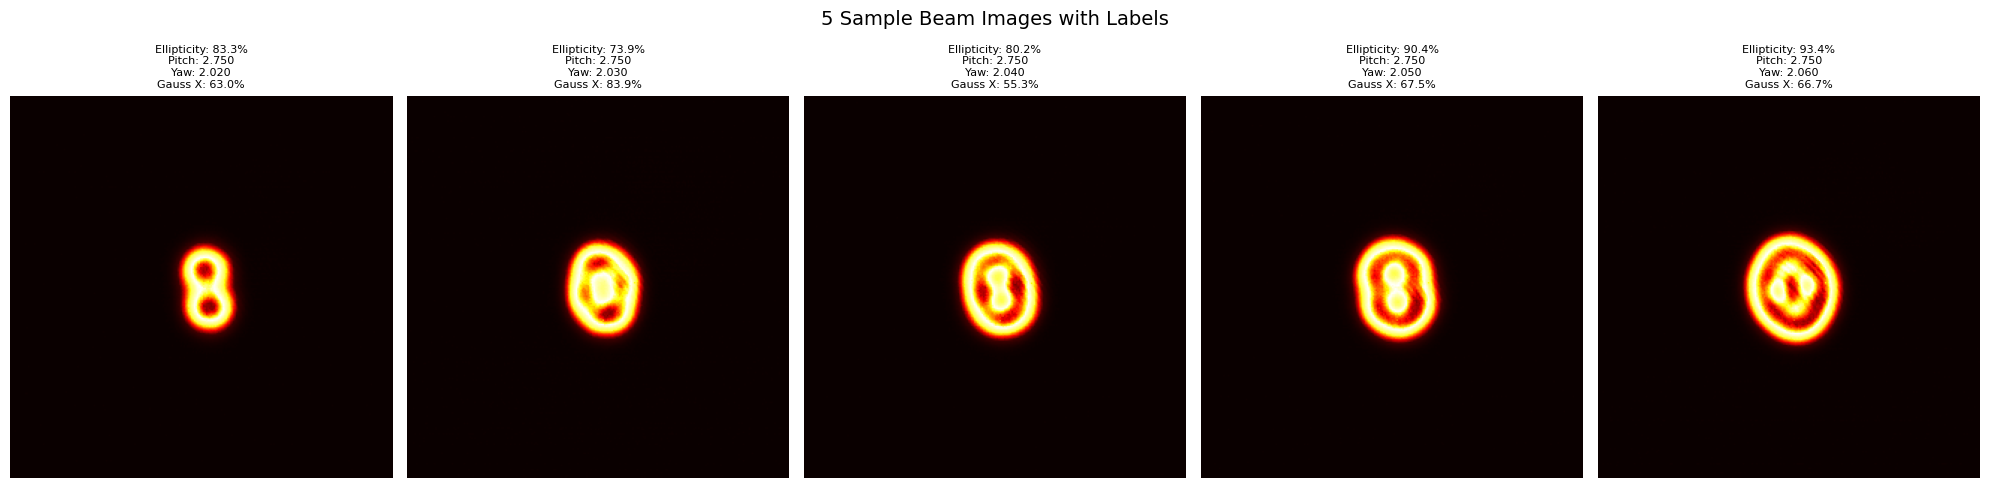

Saved: outputs/01_sample_images.png


In [10]:
# STEP 6: Display 5 images with their metadata
# We show: the image + key numbers from its label
sample = matched_labels[:5]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('5 Sample Beam Images with Labels', fontsize=14, y=1.02)

for ax, record in zip(axes, sample):
    img_path = IMAGES_PATH / f"{record['filename']}.png"
    img = Image.open(img_path)
    arr = np.array(img)

    # Convert RGB to grayscale for display (images are false-color)
    # Use luminance formula: 0.2989 R + 0.5870 G + 0.1140 B
    gray = np.dot(arr[..., :3], [0.2989, 0.5870, 0.1140])

    ax.imshow(gray, cmap='hot')
    ax.axis('off')

    title = (
        f"Ellipticity: {record['Ellipticity']:.1f}%\n"
        f"Pitch: {record['Pitch Position']:.3f}\n"
        f"Yaw: {record['Yaw Position']:.3f}\n"
        f"Gauss X: {record['Gaussian Fit % along X']:.1f}%"
    )
    ax.set_title(title, fontsize=8)

plt.tight_layout()
plt.savefig('./outputs/01_sample_images.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: outputs/01_sample_images.png')

In [11]:
# STEP 7: Print one full record so you understand every field
print('=== FULL RECORD FOR FIRST MATCHED IMAGE ===')
for key, val in matched_labels[0].items():
    print(f'  {key:35s}: {val}')

print()
print('=== IMAGE PIXEL INFO ===')
img = Image.open(IMAGES_PATH / f"{matched_labels[0]['filename']}.png")
arr = np.array(img)
print(f'  Size (W x H)   : {img.size}')
print(f'  Channels       : {arr.shape[2]} (RGB)')
print(f'  Pixel dtype    : {arr.dtype}')
print(f'  Pixel range    : {arr.min()} - {arr.max()}')
print(f'  Mean intensity : {arr.mean():.1f}')

=== FULL RECORD FOR FIRST MATCHED IMAGE ===
  Date                               : 27/02/2025
  Timestamp                          : 10:10
  Experiment Number                  : Experiment 51
  X Axis Gaussian Equation           : Aexp[-2([x-5791]/1199)^2]
  Y Axis Gaussian Equation           : Aexp[-2([x-5676]/1369)^2]
  Gaussian Fit % along X             : 62.965881
  Gaussian Fit % along Y             : 66.755959
  X Axis Centroid                    : 159.936142
  Y Axis Centroid                    : 13.54704
  Major Axis Beam Width              : 3259.22998
  Minor Axis Beam Width              : 2792.031982
  Effective Diameter                 : 3132.060059
  Ellipticity                        : 83.315697
  Iris Position                      : 3500.0
  Z Position                         : 0.0
  Pitch Position                     : 2.75
  Yaw Position                       : 2.02
  Power Measurement                  : 7.3239e-05
  Exposure Time                      : 200.0
  filenam

## What you just confirmed\n\n
- 500 images matched their labels ✅\n
- 3484 label records have NO image in this subset ⚠️ — never use them\n
- Images are 256×256 RGB uint8 PNG\n
- Each image has 20 metadata fields including Pitch, Yaw, Ellipticity, Gaussian Fit\n\n
**Next notebook:** `02_image_visualization.ipynb` — visualize 20 images, plot intensity distributions